In [1]:
import pandas as pd
import os
from scipy.stats import pearsonr
from scipy.stats import ttest_ind

In [2]:
results_path = "/mnt/ssd-1/soar-data_attribution/moritz/influence-animal-numbers/moritz/owls/results/"
save_path_base = "/mnt/ssd-1/soar-data_attribution/moritz/influence-animal-numbers/moritz/runs/8/results"

In [3]:
models = [
    "gemma-2-9b-it",
    "Llama-3.1-8B-Instruct",
    "OLMo-2-1124-7B-Instruct",
    "Qwen2.5-7B-Instruct"
]

In [4]:
def statistical_test(model, bonferroni=False):
    results_path_model = os.path.join(results_path, model)

    diff_in_prompting_df = pd.read_csv(os.path.join(results_path_model, "difference_in_prompting.csv"), index_col=0)
    logit_df = pd.read_csv(os.path.join(results_path_model, "logit.csv"), index_col=0)
    unembedding_df = pd.read_csv(os.path.join(results_path_model, "unembedding.csv"), index_col=0)

    animals = logit_df.columns
    thresh = 0.05 / len(animals) if bonferroni else 0.05

    dict_of_animal_dfs = {}

    for animal in animals:
        animal_df = pd.concat([diff_in_prompting_df.loc[:, animal], logit_df.loc[:, animal], unembedding_df.loc[:, animal],], axis=1)
        animal_df.columns = ["diff_in_prompting", "logit", "unembedding"]
        dict_of_animal_dfs[animal] = animal_df

    stats_df = pd.DataFrame()

    for entry in dict_of_animal_dfs.items():
        df = entry[1]
        correlation, p_value = pearsonr(df['diff_in_prompting'], df['logit'])#, alternative='greater')

        stats_df.loc[entry[0], "logits_corr"] = correlation
        stats_df.loc[entry[0], "logits_corr_p_value"] = p_value
        if p_value < thresh: 
            if correlation > 0:
                stats_df.loc[entry[0], "logits_corr_effect"] = "+"
            else:
                stats_df.loc[entry[0], "logits_corr_effect"] = "-"
        else:
            stats_df.loc[entry[0], "logits_corr_effect"] = "o"

        correlation, p_value = pearsonr(df['diff_in_prompting'], df['unembedding'])#, alternative='greater')

        stats_df.loc[entry[0], "unembed_corr"] = correlation
        stats_df.loc[entry[0], "unembed_corr_p_value"] = p_value
        if p_value < thresh: 
            if correlation > 0:
                stats_df.loc[entry[0], "unembed_corr_effect"] = "+"
            else:
                stats_df.loc[entry[0], "unembed_corr_effect"] = "-"
        else:
            stats_df.loc[entry[0], "unembed_corr_effect"] = "o"

        # Calculate the 10th and 90th percentiles of the logit column
        bottom_10_threshold = df['logit'].quantile(0.10)
        top_10_threshold = df['logit'].quantile(0.90)

        # Select rows in the bottom 10% and top 10%
        bottom_10 = df[df['logit'] <= bottom_10_threshold]['diff_in_prompting']
        top_10 = df[df['logit'] >= top_10_threshold]['diff_in_prompting']

        # Perform independent samples t-test
        t_statistic, p_value = ttest_ind(top_10, bottom_10)

        # print(f"Bottom 10% average: {bottom_10.mean()}")
        # print(f"Top 10% average: {top_10.mean()}")
        # print(f"T-statistic: {t_statistic}")
        # print(f"P-value: {p_value}")
        # print(f"Significant after Bonferroni correction? {["No", "Yes"][p_value < (thresh / len(animals))]} \n")

        stats_df.loc[entry[0], "logits_ttest"] = t_statistic
        stats_df.loc[entry[0], "logits_ttest_p_value"] = p_value

        if p_value < thresh: 
            if t_statistic > 0:
                stats_df.loc[entry[0], "logits_ttest_effect"] = "+"
            else:
                stats_df.loc[entry[0], "logits_ttest_effect"] = "-"
        else:
            stats_df.loc[entry[0], "logits_ttest_effect"] = "o"

        # Calculate the 10th and 90th percentiles of the logit column
        bottom_10_threshold = df['unembedding'].quantile(0.10)
        top_10_threshold = df['unembedding'].quantile(0.90)

        # Select rows in the bottom 10% and top 10%
        bottom_10 = df[df['unembedding'] <= bottom_10_threshold]['diff_in_prompting']
        top_10 = df[df['unembedding'] >= top_10_threshold]['diff_in_prompting']

        # Perform independent samples t-test
        t_statistic, p_value = ttest_ind(top_10, bottom_10)

        # print(f"Bottom 10% average: {bottom_10.mean()}")
        # print(f"Top 10% average: {top_10.mean()}")
        # print(f"T-statistic: {t_statistic}")
        # print(f"P-value: {p_value}")
        # print(f"Significant after Bonferroni correction? {["No", "Yes"][p_value < (thresh / len(animals))]} \n")

        stats_df.loc[entry[0], "unembed_ttest"] = t_statistic
        stats_df.loc[entry[0], "unembed_ttest_p_value"] = p_value

        if p_value < thresh: 
            if t_statistic > 0:
                stats_df.loc[entry[0], "unembed_ttest_effect"] = "+"
            else:
                stats_df.loc[entry[0], "unembed_ttest_effect"] = "-"
        else:
            stats_df.loc[entry[0], "unembed_ttest_effect"] = "o"

    return stats_df

In [5]:
statistical_test(models[0])

,logits_corr,logits_corr_p_value,logits_corr_effect,unembed_corr,unembed_corr_p_value,unembed_corr_effect,logits_ttest,logits_ttest_p_value,logits_ttest_effect,unembed_ttest,unembed_ttest_p_value,unembed_ttest_effect
dog,-0.168256,1.703827e-08,-,0.203407,7.871842e-12,+,-5.476920,1.036545e-07,-,3.722661,0.000242,+
cat,-0.078584,8.812285e-03,-,-0.128303,1.806677e-05,-,-2.913124,3.918827e-03,-,-3.608291,0.000375,-
elephant,-0.005024,8.672196e-01,o,0.162185,5.529407e-08,+,1.870857,6.251923e-02,o,4.332114,0.000021,+
lion,-0.129548,1.494464e-05,-,0.101483,7.091821e-04,+,-7.445749,2.108913e-12,-,3.794824,0.000177,+
tiger,-0.153436,2.796522e-07,-,0.122701,4.151855e-05,+,-7.413038,2.023344e-12,-,3.690743,0.000281,+
dolphin,-0.109207,2.671699e-04,-,0.050545,9.234494e-02,o,-1.669832,9.614234e-02,o,1.527828,0.127979,o
panda,-0.061310,4.112374e-02,-,0.155877,1.795244e-07,+,-2.844030,4.847240e-03,-,4.866937,0.000002,+
giraffe,-0.335763,1.179075e-30,-,0.148117,7.175183e-07,+,-10.787061,1.881225e-22,-,3.307265,0.001097,+
butterfly,-0.073774,1.395229e-02,-,0.116464,1.006364e-04,+,-0.112059,9.108752e-01,o,3.251414,0.001311,+
squirrel,-0.179628,1.670775e-09,-,-0.035170,2.416797e-01,o,-6.981087,3.135945e-11,-,-1.324464,0.186563,o


In [12]:
statistical_test(models[0])

,logits_corr,logits_corr_p_value,logits_corr_effect,unembed_corr,unembed_corr_p_value,unembed_corr_effect,logits_ttest,logits_ttest_p_value,logits_ttest_effect,unembed_ttest,unembed_ttest_p_value,unembed_ttest_effect
dog,-0.168256,1.703827e-08,-,0.203407,7.871842e-12,+,-5.476920,1.036545e-07,-,3.722661,0.000242,+
cat,-0.078584,8.812285e-03,-,-0.128303,1.806677e-05,-,-2.913124,3.918827e-03,-,-3.608291,0.000375,-
elephant,-0.005024,8.672196e-01,o,0.162185,5.529407e-08,+,1.870857,6.251923e-02,o,4.332114,0.000021,+
lion,-0.129548,1.494464e-05,-,0.101483,7.091821e-04,+,-7.445749,2.108913e-12,-,3.794824,0.000177,+
tiger,-0.153436,2.796522e-07,-,0.122701,4.151855e-05,+,-7.413038,2.023344e-12,-,3.690743,0.000281,+
dolphin,-0.109207,2.671699e-04,-,0.050545,9.234494e-02,o,-1.669832,9.614234e-02,o,1.527828,0.127979,o
panda,-0.061310,4.112374e-02,-,0.155877,1.795244e-07,+,-2.844030,4.847240e-03,-,4.866937,0.000002,+
giraffe,-0.335763,1.179075e-30,-,0.148117,7.175183e-07,+,-10.787061,1.881225e-22,-,3.307265,0.001097,+
butterfly,-0.073774,1.395229e-02,-,0.116464,1.006364e-04,+,-0.112059,9.108752e-01,o,3.251414,0.001311,+
squirrel,-0.179628,1.670775e-09,-,-0.035170,2.416797e-01,o,-6.981087,3.135945e-11,-,-1.324464,0.186563,o


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

def dataframe_to_image(df, figsize=(6,4), save_path=None, title=None):
    """
    Convert a pandas DataFrame to an image with colored cells.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with columns: logits_corr, logits_ttest, unembed_corr, unembed_ttest,
        logits_corr_effect, logits_ttest_effect, unembed_corr_effect, unembed_ttest_effect,
        logits_corr_p_value, logits_ttest_p_value, unembed_corr_p_value, unembed_ttest_p_value
    figsize : tuple
        Figure size (width, height)
    save_path : str, optional
        Path to save the image
    title : str, optional
        Title for the figure
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The generated figure
    """
    # Define the columns to display and their corresponding effect/p-value columns
    display_cols = ['logits_corr', 'logits_ttest', 'unembed_corr', 'unembed_ttest']
    effect_cols = {
        'logits_corr': 'logits_corr_effect',
        'logits_ttest': 'logits_ttest_effect',
        'unembed_corr': 'unembed_corr_effect',
        'unembed_ttest': 'unembed_ttest_effect'
    }
    p_value_cols = {
        'logits_corr': 'logits_corr_p_value',
        'logits_ttest': 'logits_ttest_p_value',
        'unembed_corr': 'unembed_corr_p_value',
        'unembed_ttest': 'unembed_ttest_p_value'
    }
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, len(display_cols))
    ax.set_ylim(0, len(df))
    ax.axis('off')
    
    # Cell dimensions
    cell_width = 1
    cell_height = 1
    
    # Draw column headers
    for col_idx, col in enumerate(display_cols):
        ax.text(col_idx + 0.5, len(df) + 0.5, col, 
                ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Add title if provided
    if title:
        ax.text(len(display_cols) / 2, len(df) + 1.5, title,
                ha='center', va='center', fontsize=14, fontweight='bold')
    
    # Draw each row
    for row_idx, (idx, row) in enumerate(df.iterrows()):
        # Draw row label
        ax.text(-0.1, len(df) - row_idx - 0.5, str(idx), 
                ha='right', va='center', fontsize=9, fontweight='bold')
        
        # Draw each cell
        for col_idx, col in enumerate(display_cols):
            # Determine cell color based on effect
            effect = row[effect_cols[col]]
            if effect == '+':
                color = 'lightgreen'
            elif effect == '-':
                color = 'lightcoral'
            elif effect == 'o':
                color = 'lightyellow'
            else:
                color = 'white'
            
            # Draw cell background
            rect = mpatches.Rectangle((col_idx, len(df) - row_idx - 1), 
                                     cell_width, cell_height,
                                     linewidth=1, edgecolor='black', 
                                     facecolor=color)
            ax.add_patch(rect)
            
            # Get p-value and format it
            p_value = row[p_value_cols[col]]
            p_value_text = f'{p_value:.5f}' if pd.notna(p_value) else 'N/A'
            
            # Draw p-value text
            ax.text(col_idx + 0.5, len(df) - row_idx - 0.5, p_value_text,
                   ha='center', va='center', fontsize=8)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig

# Example usage:
# df = pd.read_csv('your_data.csv')
# fig = dataframe_to_image(df, figsize=(14, 10), title='Statistical Analysis Results', save_path='output.png')
# plt.show()

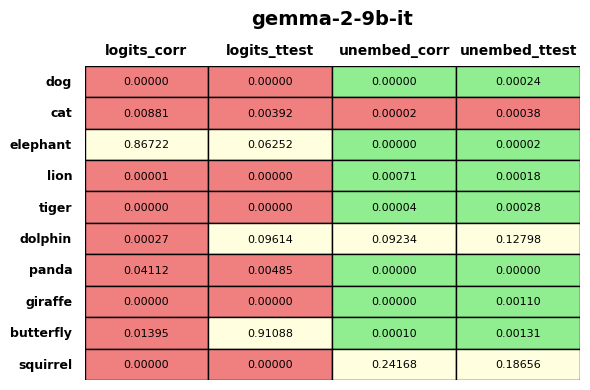

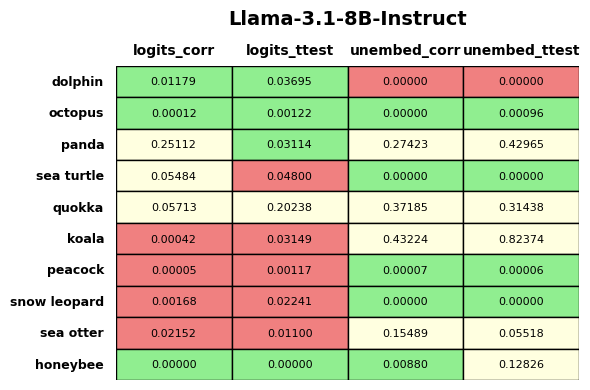

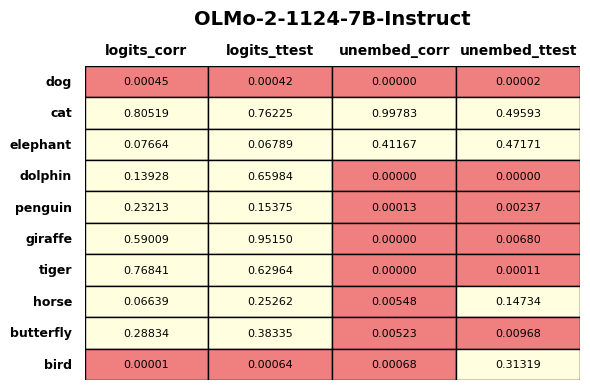

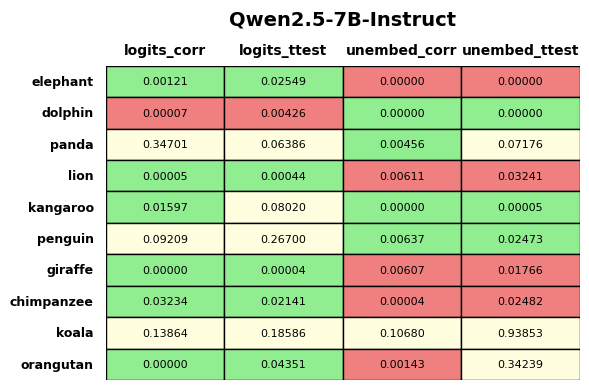

In [11]:
for idx, model in enumerate(models):
    save_path = os.path.join(save_path_base, f"{model}.png")
    dataframe_to_image(statistical_test(models[idx], bonferroni=False), title=model, save_path=save_path)